# !. Import libraries

In [154]:
import numpy as np
import pandas as pd
import sklearn
import warnings

In [155]:
%pip install feature-engine

Note: you may need to restart the kernel to use updated packages.


In [156]:
from feature_engine.encoding import (
	RareLabelEncoder,
	MeanEncoder,
	CountFrequencyEncoder
)
from feature_engine.datetime import DatetimeFeatures
from feature_engine.selection import SelectBySingleFeaturePerformance
from feature_engine.outliers import Winsorizer

In [157]:
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
	OneHotEncoder,
	OrdinalEncoder,
	StandardScaler,
	MinMaxScaler,
	PowerTransformer,
	FunctionTransformer
)

import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

# 2. Display settings

In [158]:
pd.set_option("display.max_columns", None)

In [159]:
sklearn.set_config(transform_output="pandas")

In [160]:
warnings.filterwarnings("ignore")

# 3. Read the data

In [161]:
path = r"D:\NEW_WORK_MAY 26\flight_price_prediction_sagemaker\data\train.csv"
train = pd.read_csv(path)
train

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-05-03,Mumbai,Hyderabad,10:20:00,11:50:00,90,0.0,In-flight meal not included,4995
1,Jet Airways,2019-03-21,Banglore,New Delhi,22:50:00,10:25:00,695,1.0,In-flight meal not included,7832
2,Multiple Carriers,2019-06-27,Delhi,Cochin,08:45:00,21:00:00,735,1.0,No Info,7005
3,Air India,2019-05-09,Banglore,Delhi,17:00:00,19:45:00,165,0.0,No Info,5228
4,Jet Airways,2019-05-27,Banglore,Delhi,19:50:00,22:50:00,180,0.0,No Info,7229
...,...,...,...,...,...,...,...,...,...,...
635,Indigo,2019-06-01,Banglore,Delhi,06:05:00,08:50:00,165,0.0,No Info,3943
636,Multiple Carriers,2019-06-06,Delhi,Cochin,10:20:00,01:30:00,910,1.0,No Info,6795
637,Air India,2019-05-09,Delhi,Cochin,20:40:00,09:25:00,765,1.0,No Info,7480
638,Indigo,2019-06-21,Kolkata,Banglore,17:15:00,19:50:00,155,0.0,No Info,4804


In [162]:
X_train = train.drop(columns = "price")
y_train = train.price.copy()

# 4. Transformation Operations

### 4.1 airline

In [163]:
print(RareLabelEncoder)

<class 'feature_engine.encoding.rare_label.RareLabelEncoder'>


In [164]:
import feature_engine.encoding as fe

print(dir(fe))

['CountFrequencyEncoder', 'DecisionTreeEncoder', 'MeanEncoder', 'OneHotEncoder', 'OrdinalEncoder', 'RareLabelEncoder', 'StringSimilarityEncoder', 'WoEEncoder', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_helper_functions', 'base_encoder', 'count_frequency', 'decision_tree', 'mean_encoding', 'one_hot', 'ordinal', 'rare_label', 'similarity_encoder', 'woe']


In [165]:
import feature_engine
print(feature_engine.__version__)

1.9.4


In [166]:
import sys
print(sys.executable)

C:\Users\user\anaconda3\python.exe


In [167]:
from feature_engine.encoding import RareLabelEncoder

print(RareLabelEncoder)

<class 'feature_engine.encoding.rare_label.RareLabelEncoder'>


In [168]:
airline_transformation = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("grouper", RareLabelEncoder(tol=0.1, replace_with="Other", n_categories=2)),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])
airline_transformation.fit_transform(X_train.loc[:,["airline"]])

,airline_Air India,airline_Indigo,airline_Jet Airways,airline_Multiple Carriers,airline_Other
0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
635,0.0,1.0,0.0,0.0,0.0
636,0.0,0.0,0.0,1.0,0.0
637,1.0,0.0,0.0,0.0,0.0
638,0.0,1.0,0.0,0.0,0.0


### 4.2 date_of_journey

In [169]:
feature_to_extract = ["month", "week", "day_of_week", "day_of_year"]

doj_transformer = Pipeline(steps=[
	("dt", DatetimeFeatures(features_to_extract=feature_to_extract, yearfirst=True, format="mixed")),
	("scaler", MinMaxScaler())
])

doj_transformer.fit_transform(X_train.loc[:, ["date_of_journey"]])

,date_of_journey_month,date_of_journey_week,date_of_journey_day_of_week,date_of_journey_day_of_year
0,0.666667,0.529412,0.666667,0.533898
1,0.000000,0.176471,0.500000,0.169492
2,1.000000,1.000000,0.500000,1.000000
3,0.666667,0.588235,0.500000,0.584746
4,0.666667,0.764706,0.000000,0.737288
...,...,...,...,...
635,1.000000,0.764706,0.833333,0.779661
636,1.000000,0.823529,0.500000,0.822034
637,0.666667,0.588235,0.500000,0.584746
638,1.000000,0.941176,0.666667,0.949153


### 4.3 Source and destination

In [170]:
X_train.source

0        Mumbai
1      Banglore
2         Delhi
3      Banglore
4      Banglore
         ...   
635    Banglore
636       Delhi
637       Delhi
638     Kolkata
639       Delhi
Name: source, Length: 640, dtype: object

In [171]:
X_train.destination

0      Hyderabad
1      New Delhi
2         Cochin
3          Delhi
4          Delhi
         ...    
635        Delhi
636       Cochin
637       Cochin
638     Banglore
639       Cochin
Name: destination, Length: 640, dtype: object

In [172]:
location_subset = X_train.loc[:, ["source", "destination"]]
location_subset

,source,destination
0,Mumbai,Hyderabad
1,Banglore,New Delhi
2,Delhi,Cochin
3,Banglore,Delhi
4,Banglore,Delhi
...,...,...
635,Banglore,Delhi
636,Delhi,Cochin
637,Delhi,Cochin
638,Kolkata,Banglore


In [173]:
# source and destination
location_pipe1 = Pipeline(steps=[
    ("grouper", RareLabelEncoder(tol=0.1, replace_with="Other", n_categories=2)),
    ("encoder", MeanEncoder()),
    ("scaler", PowerTransformer())
])
location_pipe1.fit_transform(location_subset, y_train)

,source,destination
0,-1.885039,-1.629423
1,-0.835540,1.468141
2,1.078019,0.667026
3,-0.835540,-1.584932
4,-0.835540,-1.584932
...,...,...
635,-0.835540,-1.584932
636,1.078019,0.667026
637,1.078019,0.667026
638,-0.158636,-0.223781


In [174]:
np.union1d(
    X_train.source.unique(),
    X_train.destination.unique()
)

array(['Banglore', 'Chennai', 'Cochin', 'Delhi', 'Hyderabad', 'Kolkata',
       'Mumbai', 'New Delhi'], dtype=object)

In [175]:
def is_north(X):
    columns = X.columns.to_list()
    north_cities = ["Delhi", "Kolkata", "Mumbai", "New Delhi"]
    return (
    X
    .assign(**{
            f"{col}_is_north" : X.loc[:, col].isin(north_cities).astype(int)
            for col in columns
    })
    .drop(columns=columns)
    )

FunctionTransformer(func=is_north).fit_transform(location_subset)

,source_is_north,destination_is_north
0,1,0
1,0,1
2,1,0
3,0,1
4,0,1
...,...,...
635,0,1
636,1,0
637,1,0
638,1,0


In [176]:
location_transformer = FeatureUnion(transformer_list=[
	("part1", location_pipe1),
	("part2", FunctionTransformer(func=is_north))
])

location_transformer.fit_transform(location_subset, y_train)

,source,destination,source_is_north,destination_is_north
0,-1.885039,-1.629423,1,0
1,-0.835540,1.468141,0,1
2,1.078019,0.667026,1,0
3,-0.835540,-1.584932,0,1
4,-0.835540,-1.584932,0,1
...,...,...,...,...
635,-0.835540,-1.584932,0,1
636,1.078019,0.667026,1,0
637,1.078019,0.667026,1,0
638,-0.158636,-0.223781,1,0


### 4.4 dep_time and arrival_time

In [177]:
X_train.dep_time

0      10:20:00
1      22:50:00
2      08:45:00
3      17:00:00
4      19:50:00
         ...   
635    06:05:00
636    10:20:00
637    20:40:00
638    17:15:00
639    13:00:00
Name: dep_time, Length: 640, dtype: object

In [178]:
X_train.arrival_time

0      11:50:00
1      10:25:00
2      21:00:00
3      19:45:00
4      22:50:00
         ...   
635    08:50:00
636    01:30:00
637    09:25:00
638    19:50:00
639    19:00:00
Name: arrival_time, Length: 640, dtype: object

In [179]:
time_subset = X_train.loc[:, ["dep_time", "arrival_time"]]
time_subset

,dep_time,arrival_time
0,10:20:00,11:50:00
1,22:50:00,10:25:00
2,08:45:00,21:00:00
3,17:00:00,19:45:00
4,19:50:00,22:50:00
...,...,...
635,06:05:00,08:50:00
636,10:20:00,01:30:00
637,20:40:00,09:25:00
638,17:15:00,19:50:00


In [180]:
time_pipe1 = Pipeline(steps=[
    ("dt", DatetimeFeatures(features_to_extract=["hour", "minute"])),
    ("scaler", MinMaxScaler())
])
time_pipe1.fit_transform(time_subset)

,dep_time_hour,dep_time_minute,arrival_time_hour,arrival_time_minute
0,0.434783,0.363636,0.478261,0.909091
1,0.956522,0.909091,0.434783,0.454545
2,0.347826,0.818182,0.913043,0.000000
3,0.739130,0.000000,0.826087,0.818182
4,0.826087,0.909091,0.956522,0.909091
...,...,...,...,...
635,0.260870,0.090909,0.347826,0.909091
636,0.434783,0.363636,0.043478,0.545455
637,0.869565,0.727273,0.391304,0.454545
638,0.739130,0.272727,0.826087,0.909091


In [181]:
def part_of_day(X, morning=4, noon=12, eve=16, night=20):
	columns = X.columns.to_list()
	X_temp = X.assign(**{
		col: pd.to_datetime(X.loc[:, col]).dt.hour
		for col in columns
	})

	return (
		X_temp
		.assign(**{
			f"{col}_part_of_day": np.select(
				[X_temp.loc[:, col].between(morning, noon, inclusive="left"),
				 X_temp.loc[:, col].between(noon, eve, inclusive="left"),
				 X_temp.loc[:, col].between(eve, night, inclusive="left")],
				["morning", "afternoon", "evening"],
				default="night"
			)
			for col in columns
		})
		.drop(columns=columns)
	)

FunctionTransformer(func=part_of_day).fit_transform(time_subset)

,dep_time_part_of_day,arrival_time_part_of_day
0,morning,morning
1,night,morning
2,morning,night
3,evening,evening
4,evening,night
...,...,...
635,morning,morning
636,morning,night
637,night,morning
638,evening,evening


In [182]:
time_pipe2 = Pipeline(steps=[
	("part", FunctionTransformer(func=part_of_day)),
	("encoder", CountFrequencyEncoder()),
	("scaler", MinMaxScaler())
])

time_pipe2.fit_transform(time_subset)

,dep_time_part_of_day,arrival_time_part_of_day
0,1.000000,0.895833
1,0.133333,0.895833
2,1.000000,1.000000
3,0.180952,0.604167
4,0.180952,1.000000
...,...,...
635,1.000000,0.895833
636,1.000000,1.000000
637,0.133333,0.895833
638,0.180952,0.604167


In [183]:

time_transformer = FeatureUnion(transformer_list=[
	("part1", time_pipe1),
	("part2", time_pipe2)
])

time_transformer.fit_transform(time_subset)

,dep_time_hour,dep_time_minute,arrival_time_hour,arrival_time_minute,dep_time_part_of_day,arrival_time_part_of_day
0,0.434783,0.363636,0.478261,0.909091,1.000000,0.895833
1,0.956522,0.909091,0.434783,0.454545,0.133333,0.895833
2,0.347826,0.818182,0.913043,0.000000,1.000000,1.000000
3,0.739130,0.000000,0.826087,0.818182,0.180952,0.604167
4,0.826087,0.909091,0.956522,0.909091,0.180952,1.000000
...,...,...,...,...,...,...
635,0.260870,0.090909,0.347826,0.909091,1.000000,0.895833
636,0.434783,0.363636,0.043478,0.545455,1.000000,1.000000
637,0.869565,0.727273,0.391304,0.454545,0.133333,0.895833
638,0.739130,0.272727,0.826087,0.909091,0.180952,0.604167


## 4.5 Duration

In [184]:
X_train.duration

0       90
1      695
2      735
3      165
4      180
      ... 
635    165
636    910
637    765
638    155
639    360
Name: duration, Length: 640, dtype: int64

In [185]:
(
    X_train
    .duration
    .quantile([0.25, 0.5, 0.75])
    .values
    .reshape(-1, 1)
)

array([[170. ],
       [477.5],
       [925. ]])

In [186]:
class RBFPercentileSimilarity(BaseEstimator, TransformerMixin):
	def __init__(self, variables=None, percentiles=[0.25, 0.5, 0.75], gamma=0.1):
		self.variables = variables
		self.percentiles = percentiles
		self.gamma = gamma


	def fit(self, X, y=None):
		if not self.variables:
			self.variables = X.select_dtypes(include="number").columns.to_list()

		self.reference_values_ = {
			col: (
				X
				.loc[:, col]
				.quantile(self.percentiles)
				.values
				.reshape(-1, 1)
			)
			for col in self.variables
		}

		return self


	def transform(self, X):
		objects = []
		for col in self.variables:
			columns = [f"{col}_rbf_{int(percentile * 100)}" for percentile in self.percentiles]
			obj = pd.DataFrame(
				data=rbf_kernel(X.loc[:, [col]], Y=self.reference_values_[col], gamma=self.gamma),
				columns=columns
			)
			objects.append(obj)
		return pd.concat(objects, axis=1)

In [187]:
RBFPercentileSimilarity(percentiles=[0.4, 0.8]).fit_transform(X_train)

,duration_rbf_40,duration_rbf_80,total_stops_rbf_40,total_stops_rbf_80
0,0.000000e+00,0.0,0.904837,0.904837
1,0.000000e+00,0.0,1.000000,1.000000
2,0.000000e+00,0.0,1.000000,1.000000
3,0.000000e+00,0.0,0.904837,0.904837
4,0.000000e+00,0.0,0.904837,0.904837
...,...,...,...,...
635,0.000000e+00,0.0,0.904837,0.904837
636,0.000000e+00,0.0,1.000000,1.000000
637,0.000000e+00,0.0,1.000000,1.000000
638,0.000000e+00,0.0,0.904837,0.904837


In [188]:
def duration_category(X, short=180, med=400):
    return(
        X
        .assign(duration_cat=np.select([X.duration.lt(short),
									    X.duration.between(short, med, inclusive="left")],
									   ["short", "medium"],
									   default="long"))
		.drop(columns="duration")
	)

In [189]:
def is_over(X, value=1000):
	return (
		X
		.assign(**{
			f"duration_over_{value}": X.duration.ge(value).astype(int)
		})
		.drop(columns="duration")
	)

In [190]:
duration_pipe1 = Pipeline(steps=[
	("rbf", RBFPercentileSimilarity()),
	("scaler", PowerTransformer())
])

duration_pipe2 = Pipeline(steps=[
	("cat", FunctionTransformer(func=duration_category)),
	("encoder", OrdinalEncoder(categories=[["short", "medium", "long"]]))
])

duration_union = FeatureUnion(transformer_list=[
	("part1", duration_pipe1),
	("part2", duration_pipe2),
	("part3", FunctionTransformer(func=is_over)),
	("part4", StandardScaler())
])

duration_transformer = Pipeline(steps=[
	("outliers", Winsorizer(capping_method="iqr", fold=1.5)),
	("imputer", SimpleImputer(strategy="median")),
	("union", duration_union)
])

duration_transformer.fit_transform(X_train.loc[:, ["duration"]])

,duration_rbf_25,duration_rbf_50,duration_rbf_75,duration_cat,duration_over_1000,duration
0,-0.382440,-0.112205,-0.097527,0.0,0,-1.071537
1,-0.382440,-0.112205,-0.097527,2.0,0,0.124465
2,-0.382440,-0.112205,-0.097527,2.0,0,0.203540
3,2.246931,-0.112205,-0.097527,0.0,0,-0.923273
4,-0.379545,-0.112205,-0.097527,1.0,0,-0.893620
...,...,...,...,...,...,...
635,2.246931,-0.112205,-0.097527,0.0,0,-0.923273
636,-0.382440,-0.112205,-0.097526,2.0,0,0.549491
637,-0.382440,-0.112205,-0.097527,2.0,0,0.262846
638,-0.382440,-0.112205,-0.097527,0.0,0,-0.943041


### 4.6 Total stops

In [191]:
X_train.total_stops

0      0.0
1      1.0
2      1.0
3      0.0
4      0.0
      ... 
635    0.0
636    1.0
637    1.0
638    0.0
639    1.0
Name: total_stops, Length: 640, dtype: float64

In [192]:
def is_direct(X):
	return X.assign(is_direct_flight=X.total_stops.eq(0).astype(int))


total_stops_transformer = Pipeline(steps=[
	("imputer", SimpleImputer(strategy="most_frequent")),
	("is_direct", FunctionTransformer(func=is_direct))
])

total_stops_transformer.fit_transform(X_train.loc[:, ["total_stops"]])

,total_stops,is_direct_flight
0,0.0,1
1,1.0,0
2,1.0,0
3,0.0,1
4,0.0,1
...,...,...
635,0.0,1
636,1.0,0
637,1.0,0
638,0.0,1


### 4.7 additional_info

In [193]:
X_train.additional_info

0      In-flight meal not included
1      In-flight meal not included
2                          No Info
3                          No Info
4                          No Info
                  ...             
635                        No Info
636                        No Info
637                        No Info
638                        No Info
639                        No Info
Name: additional_info, Length: 640, dtype: object

In [194]:
info_pipe1 = Pipeline(steps=[
    ("group", RareLabelEncoder(tol=0.1, n_categories=2, replace_with="Other")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
info_pipe1.fit_transform(X_train.loc[:, ["additional_info"]])

,additional_info_In-flight meal not included,additional_info_No Info,additional_info_Other
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
635,0.0,1.0,0.0
636,0.0,1.0,0.0
637,0.0,1.0,0.0
638,0.0,1.0,0.0


In [195]:
def have_info(X):
	return X.assign(additional_info=X.additional_info.ne("No Info").astype(int))

In [196]:
info_union = FeatureUnion(transformer_list=[
	("part1", info_pipe1),
	("part2", FunctionTransformer(func=have_info))
])

In [197]:
info_transformer = Pipeline(steps=[
	("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
	("union", info_union)
])

info_transformer.fit_transform(X_train.loc[:, ["additional_info"]])

,additional_info_In-flight meal not included,additional_info_No Info,additional_info_Other,additional_info
0,1.0,0.0,0.0,1
1,1.0,0.0,0.0,1
2,0.0,1.0,0.0,0
3,0.0,1.0,0.0,0
4,0.0,1.0,0.0,0
...,...,...,...,...
635,0.0,1.0,0.0,0
636,0.0,1.0,0.0,0
637,0.0,1.0,0.0,0
638,0.0,1.0,0.0,0


### 4.8 Column Transformer

In [198]:
from sklearn.compose import ColumnTransformer

In [199]:
column_transformer = ColumnTransformer(transformers=[
	("air", airline_transformation, ["airline"]),
	("doj", doj_transformer, ["date_of_journey"]),
	("location", location_transformer, ["source", 'destination']),
	("time", time_transformer, ["dep_time", "arrival_time"]),
	("dur", duration_transformer, ["duration"]),
	("stops", total_stops_transformer, ["total_stops"]),
	("info", info_transformer, ["additional_info"])
], remainder="passthrough")

column_transformer.fit_transform(X_train, y_train)

,air__airline_Air India,air__airline_Indigo,air__airline_Jet Airways,air__airline_Multiple Carriers,air__airline_Other,doj__date_of_journey_month,doj__date_of_journey_week,doj__date_of_journey_day_of_week,doj__date_of_journey_day_of_year,location__source,location__destination,location__source_is_north,location__destination_is_north,time__dep_time_hour,time__dep_time_minute,time__arrival_time_hour,time__arrival_time_minute,time__dep_time_part_of_day,time__arrival_time_part_of_day,dur__duration_rbf_25,dur__duration_rbf_50,dur__duration_rbf_75,dur__duration_cat,dur__duration_over_1000,dur__duration,stops__total_stops,stops__is_direct_flight,info__additional_info_In-flight meal not included,info__additional_info_No Info,info__additional_info_Other,info__additional_info
0,0.0,0.0,1.0,0.0,0.0,0.666667,0.529412,0.666667,0.533898,-1.885039,-1.629423,1,0,0.434783,0.363636,0.478261,0.909091,1.000000,0.895833,-0.382440,-0.112205,-0.097527,0.0,0,-1.071537,0.0,1,1.0,0.0,0.0,1
1,0.0,0.0,1.0,0.0,0.0,0.000000,0.176471,0.500000,0.169492,-0.835540,1.468141,0,1,0.956522,0.909091,0.434783,0.454545,0.133333,0.895833,-0.382440,-0.112205,-0.097527,2.0,0,0.124465,1.0,0,1.0,0.0,0.0,1
2,0.0,0.0,0.0,1.0,0.0,1.000000,1.000000,0.500000,1.000000,1.078019,0.667026,1,0,0.347826,0.818182,0.913043,0.000000,1.000000,1.000000,-0.382440,-0.112205,-0.097527,2.0,0,0.203540,1.0,0,0.0,1.0,0.0,0
3,1.0,0.0,0.0,0.0,0.0,0.666667,0.588235,0.500000,0.584746,-0.835540,-1.584932,0,1,0.739130,0.000000,0.826087,0.818182,0.180952,0.604167,2.246931,-0.112205,-0.097527,0.0,0,-0.923273,0.0,1,0.0,1.0,0.0,0
4,0.0,0.0,1.0,0.0,0.0,0.666667,0.764706,0.000000,0.737288,-0.835540,-1.584932,0,1,0.826087,0.909091,0.956522,0.909091,0.180952,1.000000,-0.379545,-0.112205,-0.097527,1.0,0,-0.893620,0.0,1,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,0.0,1.0,0.0,0.0,0.0,1.000000,0.764706,0.833333,0.779661,-0.835540,-1.584932,0,1,0.260870,0.090909,0.347826,0.909091,1.000000,0.895833,2.246931,-0.112205,-0.097527,0.0,0,-0.923273,0.0,1,0.0,1.0,0.0,0
636,0.0,0.0,0.0,1.0,0.0,1.000000,0.823529,0.500000,0.822034,1.078019,0.667026,1,0,0.434783,0.363636,0.043478,0.545455,1.000000,1.000000,-0.382440,-0.112205,-0.097526,2.0,0,0.549491,1.0,0,0.0,1.0,0.0,0
637,1.0,0.0,0.0,0.0,0.0,0.666667,0.588235,0.500000,0.584746,1.078019,0.667026,1,0,0.869565,0.727273,0.391304,0.454545,0.133333,0.895833,-0.382440,-0.112205,-0.097527,2.0,0,0.262846,1.0,0,0.0,1.0,0.0,0
638,0.0,1.0,0.0,0.0,0.0,1.000000,0.941176,0.666667,0.949153,-0.158636,-0.223781,1,0,0.739130,0.272727,0.826087,0.909091,0.180952,0.604167,-0.382440,-0.112205,-0.097527,0.0,0,-0.943041,0.0,1,0.0,1.0,0.0,0


# 5. Feature Selection

In [200]:
estimator = RandomForestRegressor(n_estimators=10, max_depth=3, random_state=42)

selector = SelectBySingleFeaturePerformance(
    estimator=estimator,
    scoring="r2",
    threshold=0.1
)

# 6. Putting it all together

In [201]:
preprocessor

,steps,"[('ct', ...), ('selector', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('air', ...), ('doj', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [202]:
preprocessor = Pipeline(steps=[
	("ct", column_transformer),
	("selector", selector)
])

preprocessor.fit_transform(X_train, y_train)

,air__airline_Indigo,air__airline_Jet Airways,doj__date_of_journey_week,doj__date_of_journey_day_of_year,location__destination,dur__duration_rbf_25,dur__duration_cat,dur__duration,stops__total_stops,stops__is_direct_flight
0,0.0,1.0,0.529412,0.533898,-1.629423,-0.382440,0.0,-1.071537,0.0,1
1,0.0,1.0,0.176471,0.169492,1.468141,-0.382440,2.0,0.124465,1.0,0
2,0.0,0.0,1.000000,1.000000,0.667026,-0.382440,2.0,0.203540,1.0,0
3,0.0,0.0,0.588235,0.584746,-1.584932,2.246931,0.0,-0.923273,0.0,1
4,0.0,1.0,0.764706,0.737288,-1.584932,-0.379545,1.0,-0.893620,0.0,1
...,...,...,...,...,...,...,...,...,...,...
635,1.0,0.0,0.764706,0.779661,-1.584932,2.246931,0.0,-0.923273,0.0,1
636,0.0,0.0,0.823529,0.822034,0.667026,-0.382440,2.0,0.549491,1.0,0
637,0.0,0.0,0.588235,0.584746,0.667026,-0.382440,2.0,0.262846,1.0,0
638,1.0,0.0,0.941176,0.949153,-0.223781,-0.382440,0.0,-0.943041,0.0,1


# 7. Visualizations

In [203]:
preprocessor.named_steps.keys()

dict_keys(['ct', 'selector'])

In [204]:
preprocessor.named_steps['selector']

,estimator,RandomForestR...ndom_state=42)
,scoring,'r2'
,cv,3
,groups,None
,threshold,0.1
,variables,None
,confirm_variables,False
,n_estimators,10
,criterion,'squared_error'
,max_depth,3
,min_samples_split,2


In [205]:
feature_performances = preprocessor.named_steps['selector'].feature_performance_
feature_performances

{'air__airline_Air India': np.float64(-0.0017003770308570143),
 'air__airline_Indigo': np.float64(0.12465999735093043),
 'air__airline_Jet Airways': np.float64(0.19240251189456048),
 'air__airline_Multiple Carriers': np.float64(0.010036186800214156),
 'air__airline_Other': np.float64(0.09020928406292827),
 'doj__date_of_journey_month': np.float64(0.05553309313241258),
 'doj__date_of_journey_week': np.float64(0.13197183410538735),
 'doj__date_of_journey_day_of_week': np.float64(-0.012429022117731744),
 'doj__date_of_journey_day_of_year': np.float64(0.14256073730582577),
 'location__source': np.float64(0.09977154234124523),
 'location__destination': np.float64(0.1822910951601365),
 'location__source_is_north': np.float64(0.026954442442416404),
 'location__destination_is_north': np.float64(0.026954442442416404),
 'time__dep_time_hour': np.float64(-0.01860204119443698),
 'time__dep_time_minute': np.float64(0.01143890882953924),
 'time__arrival_time_hour': np.float64(0.08723432785368157),
 

In [206]:
sorted_feat_imp = dict(sorted(feature_performances.items(), key=lambda val:val[1]))
sorted_feat_imp

{'time__dep_time_part_of_day': np.float64(-0.019305857554483108),
 'time__dep_time_hour': np.float64(-0.01860204119443698),
 'dur__duration_rbf_50': np.float64(-0.01852193423141028),
 'doj__date_of_journey_day_of_week': np.float64(-0.012429022117731744),
 'air__airline_Air India': np.float64(-0.0017003770308570143),
 'dur__duration_rbf_75': np.float64(-0.0001958047153755397),
 'info__additional_info_In-flight meal not included': np.float64(0.00021215159670292158),
 'info__additional_info_No Info': np.float64(0.0009117210108835113),
 'info__additional_info': np.float64(0.0009117210108835113),
 'time__arrival_time_part_of_day': np.float64(0.00798921000521243),
 'air__airline_Multiple Carriers': np.float64(0.010036186800214156),
 'time__dep_time_minute': np.float64(0.01143890882953924),
 'location__source_is_north': np.float64(0.026954442442416404),
 'location__destination_is_north': np.float64(0.026954442442416404),
 'info__additional_info_Other': np.float64(0.036911040934666794),
 'time

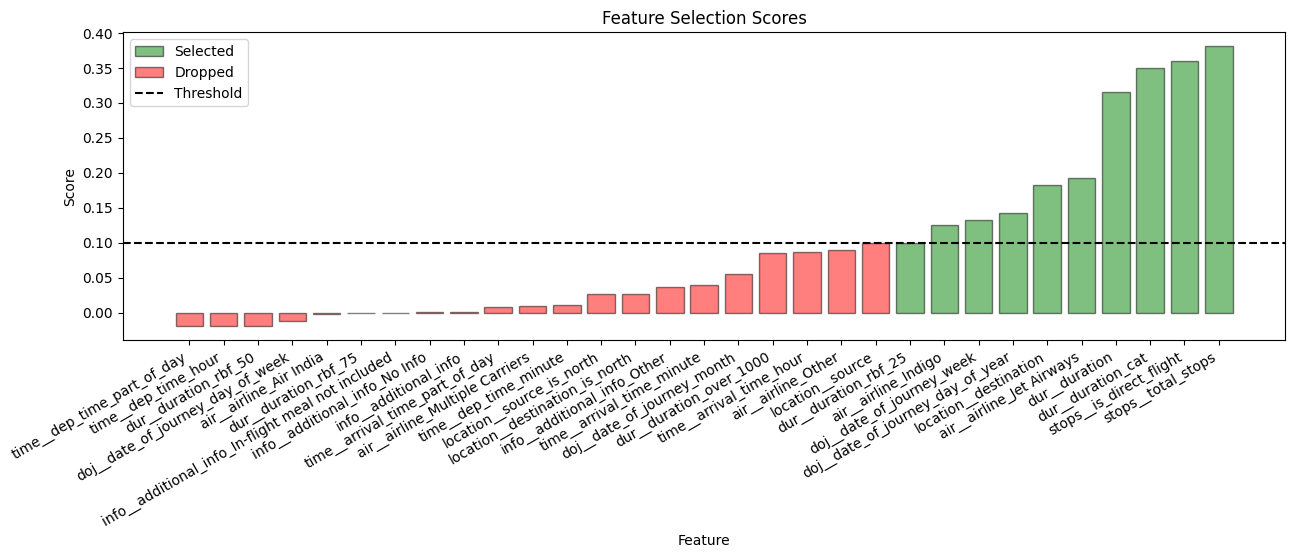

In [207]:
THRESHOLD = 0.1

selected_bar = None
dropped_bar = None
colors = ["red" if score < THRESHOLD else "green" for score in sorted_feat_imp.values()]


fig, ax = plt.subplots(figsize=(15, 4)) 

for i, (feature, score) in enumerate(sorted_feat_imp.items()):
	params = dict(
		x=i,
		height=score,
		edgecolor="black",
		alpha=0.5
	)
	
	if score < THRESHOLD:
		bar = ax.bar(
			color="red",
			**params
		)
		if not dropped_bar:
			dropped_bar = bar[0]
	else:
		bar = ax.bar(
			color="green",
			**params
		)
		if not selected_bar:
			selected_bar = bar[0]

thresh_line = ax.axhline(
	y=0.1,
	color="black",
	linestyle="--"
)

ax.set_xticks(
	ticks=range(len(sorted_feat_imp)),
	labels=list(sorted_feat_imp.keys()),
	rotation=30,
	ha="right"
)

ax.set(
	xlabel="Feature",
	ylabel="Score",
	title="Feature Selection Scores"
)

ax.legend(
	handles=[selected_bar, dropped_bar, thresh_line],
	labels=["Selected", "Dropped", "Threshold"],
	loc="upper left"
)

plt.show()